In [13]:
"""
2D Molecular Wireframe with Atom Highlighting

Generates 2D wireframe plots of molecules from XYZ files with specific atom highlighting.
Similar to the example image provided, with bonds and highlighted atoms.

Usage:
    viz = MoleculeWireframe('molecule.xyz')
    fig, ax = viz.plot(highlight_atom='C1', highlight_color='red')
    plt.show()
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# RDKit imports
from rdkit import Chem
from rdkit.Chem import AllChem

# Constants from your code
COVALENT_RADII = {
    "C": 0.76,
    "H": 0.31,
    "S": 1.05,
    "O": 0.66,
    "N": 0.71,
    "P": 1.07,
    "F": 0.57,
    "Cl": 0.99,
    "Br": 1.14,
    "I": 1.33,
}

ATOMIC_COLORS = {
    "C": "black",
    "H": "lightgray",
    "O": "red",
    "N": "blue",
    "S": "yellow",
    "P": "orange",
    "F": "green",
    "Cl": "green",
    "Br": "brown",
    "I": "purple",
}

ATOMIC_SIZES = {
    "C": 400,
    "H": 250,
    "O": 350,
    "N": 350,
    "S": 400,
    "P": 400,
    "F": 300,
    "Cl": 350,
    "Br": 400,
    "I": 450,
}


def get_atom_type(atom_label):
    """Extract atom type from label like 'C01' -> 'C'"""
    return "".join(c for c in atom_label if c.isalpha())


def load_xyz(filename):
    """Load an XYZ file and return a DataFrame.

    Skips the first two rows only if the first line can be parsed as an integer
    (atom count), and the second line is a string (comment). Otherwise, reads all rows.
    """
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Check if first line is a number (atom count) and second is a string (comment)
    try:
        int(lines[0].strip())
        skip_header = True
    except (ValueError, IndexError):
        skip_header = False

    if skip_header and len(lines) > 2:
        data_lines = lines[2:]
    else:
        data_lines = lines

    from io import StringIO
    import pandas as pd

    df = pd.read_csv(StringIO(''.join(data_lines)), sep=r"\s+", header=None)
    df.columns = ["atom", "x", "y", "z"]
    return df


def calculate_bonds(df, tolerance=0.3):
    """
    Calculate bonds between atoms based on covalent radii.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with columns ['atom', 'x', 'y', 'z']
    tolerance : float, optional
        Tolerance for bond detection (Angstroms)

    Returns
    -------
    list of tuple
        List of (idx1, idx2, atom1_label, atom2_label) tuples representing bonds
    """
    bonds = []
    positions = df[["x", "y", "z"]].values

    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            idx1, idx2 = df.index[i], df.index[j]
            atom1_label = df.loc[idx1, "atom"]
            atom2_label = df.loc[idx2, "atom"]
            atom1_type = get_atom_type(atom1_label)
            atom2_type = get_atom_type(atom2_label)

            if atom1_type not in COVALENT_RADII or atom2_type not in COVALENT_RADII:
                continue

            expected_length = COVALENT_RADII[atom1_type] + COVALENT_RADII[atom2_type]
            actual_distance = np.linalg.norm(positions[i] - positions[j])

            if actual_distance <= expected_length + tolerance:
                bonds.append((idx1, idx2, atom1_label, atom2_label))

    return bonds


class MoleculeWireframe:
    """2D wireframe visualization with atom highlighting."""

    def __init__(self, xyz_file):
        """
        Initialize with XYZ file.

        Parameters
        ----------
        xyz_file : str or Path
            Path to XYZ file
        """
        self.xyz_file = Path(xyz_file)
        self.df = load_xyz(str(self.xyz_file))
        self.bonds = calculate_bonds(self.df)

        print(f"✓ Loaded {len(self.df)} atoms from {self.xyz_file.name}")
        print(f"  Atoms: {sorted(self.df['atom'].unique())}")
        print(f"  Detected {len(self.bonds)} bonds")

    def plot(
        self,
        highlight_atom=None,
        highlight_color="red",
        highlight_size_boost=2.0,
        figsize=(12, 10),
        show_hydrogen=True,
        show_bonds=True,
        bond_width=2,
        title=None,
        save_path=None,
    ):
        """
        Create 2D wireframe plot with optional atom highlighting.

        Parameters
        ----------
        highlight_atom : str, optional
            Atom label to highlight (e.g., 'C1', 'N1', 'Zn1')
        highlight_color : str, optional
            Color for highlighted atom (default: 'red')
        highlight_size_boost : float, optional
            Size multiplier for highlighted atom (default: 2.0)
        figsize : tuple, optional
            Figure size in inches
        show_hydrogen : bool, optional
            Whether to show hydrogen atoms (default: True)
        show_bonds : bool, optional
            Whether to draw bond lines (default: True)
        bond_width : float, optional
            Width of bond lines
        title : str, optional
            Plot title
        save_path : str or Path, optional
            Path to save figure

        Returns
        -------
        fig, ax : matplotlib figure and axes
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Validate highlight atom
        if highlight_atom and highlight_atom not in self.df["atom"].values:
            available = ", ".join(sorted(self.df["atom"].unique()))
            raise ValueError(
                f"Atom '{highlight_atom}' not found. Available: {available}"
            )

        # Filter atoms (optionally hide H)
        plot_df = self.df.copy()
        if not show_hydrogen:
            plot_df = plot_df[~plot_df["atom"].str.startswith("H")].copy()

        # Draw bonds first (behind atoms)
        if show_bonds:
            for idx1, idx2, label1, label2 in self.bonds:
                # Skip if either atom is filtered out
                if idx1 not in plot_df.index or idx2 not in plot_df.index:
                    continue

                x_coords = [self.df.loc[idx1, "x"], self.df.loc[idx2, "x"]]
                y_coords = [self.df.loc[idx1, "y"], self.df.loc[idx2, "y"]]

                ax.plot(
                    x_coords,
                    y_coords,
                    "k-",
                    linewidth=bond_width,
                    alpha=0.6,
                    zorder=2,
                )

        # Draw atoms
        for idx, row in plot_df.iterrows():
            atom_type = get_atom_type(row["atom"])
            atom_label = row["atom"]
            color = ATOMIC_COLORS.get(atom_type, "gray")
            size = ATOMIC_SIZES.get(atom_type, 300)

            # Highlight specific atom
            if atom_label == highlight_atom:
                color = highlight_color
                size = size * highlight_size_boost
                # Draw highlighted atom with strong edge
                ax.scatter(
                    row["x"],
                    row["y"],
                    c=[color],
                    s=size,
                    edgecolors="black",
                    linewidths=3,
                    zorder=10,
                    label=f"{atom_label} (highlighted)",
                )
            else:
                ax.scatter(
                    row["x"],
                    row["y"],
                    c=[color],
                    s=size,
                    edgecolors="black",
                    linewidths=1.5,
                    alpha=0.85,
                    zorder=5,
                )

            # Add atom labels
            label_color = "white" if atom_type in ["C", "N", "S"] else "black"
            ax.text(
                row["x"],
                row["y"],
                atom_label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=label_color,
                zorder=11,
            )

        # Formatting
        ax.set_xlabel("X coordinate (Ų)", fontsize=12)
        ax.set_ylabel("Y coordinate (Ų)", fontsize=12)

        if title is None:
            title = f"Molecular Structure"
            if highlight_atom:
                title += f" (Highlighting {highlight_atom})"
        ax.set_title(title, fontsize=14, fontweight="bold")

        ax.grid(True, alpha=0.3, linestyle="--")
        ax.set_aspect("equal")

        # Legend
        if highlight_atom:
            ax.legend(loc="upper right", fontsize=10)

        plt.tight_layout()

        if save_path:
            save_path = Path(save_path)
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"✓ Saved figure to {save_path}")

        return fig, ax

    def plot_subplots(
        self,
        highlight_atoms=None,
        figsize=(16, 12),
        ncols=2,
        **kwargs,
    ):
        """
        Create multiple 2D wireframe plots in a grid.

        Parameters
        ----------
        highlight_atoms : list of str, optional
            List of atom labels to highlight (one per subplot)
        figsize : tuple, optional
            Total figure size
        ncols : int, optional
            Number of columns in subplot grid
        **kwargs : dict
            Additional arguments passed to plot()

        Returns
        -------
        fig, axes : matplotlib figure and axes array
        """
        if highlight_atoms is None:
            highlight_atoms = [None]

        nrows = (len(highlight_atoms) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1 or ncols == 1:
            axes = axes.reshape(nrows, ncols)

        for idx, atom_to_highlight in enumerate(highlight_atoms):
            row = idx // ncols
            col = idx % ncols
            ax = axes[row, col]

            # Replot for each subplot
            plot_df = self.df.copy()
            if not kwargs.get("show_hydrogen", True):
                plot_df = plot_df[~plot_df["atom"].str.startswith("H")].copy()

            # Draw bonds
            if kwargs.get("show_bonds", True):
                for idx1, idx2, label1, label2 in self.bonds:
                    if idx1 not in plot_df.index or idx2 not in plot_df.index:
                        continue
                    x_coords = [self.df.loc[idx1, "x"], self.df.loc[idx2, "x"]]
                    y_coords = [self.df.loc[idx1, "y"], self.df.loc[idx2, "y"]]
                    ax.plot(
                        x_coords,
                        y_coords,
                        "k-",
                        linewidth=kwargs.get("bond_width", 2),
                        alpha=0.6,
                        zorder=2,
                    )

            # Draw atoms
            for pidx, row in plot_df.iterrows():
                atom_type = get_atom_type(row["atom"])
                atom_label = row["atom"]
                color = ATOMIC_COLORS.get(atom_type, "gray")
                size = ATOMIC_SIZES.get(atom_type, 300)

                if atom_label == atom_to_highlight:
                    color = kwargs.get("highlight_color", "red")
                    size = size * kwargs.get("highlight_size_boost", 2.0)
                    ax.scatter(
                        row["x"],
                        row["y"],
                        c=[color],
                        s=size,
                        edgecolors="black",
                        linewidths=3,
                        zorder=10,
                    )
                else:
                    ax.scatter(
                        row["x"],
                        row["y"],
                        c=[color],
                        s=size,
                        edgecolors="black",
                        linewidths=1.5,
                        alpha=0.85,
                        zorder=5,
                    )

                label_color = "white" if atom_type in ["C", "N", "S"] else "black"
                ax.text(
                    row["x"],
                    row["y"],
                    atom_label,
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color=label_color,
                    zorder=11,
                )

            # Formatting
            ax.set_xlabel("X (Ų)", fontsize=10)
            ax.set_ylabel("Y (Ų)", fontsize=10)
            title = "Molecular Structure"
            if atom_to_highlight:
                title += f" ({atom_to_highlight})"
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.grid(True, alpha=0.3, linestyle="--")
            ax.set_aspect("equal")

        # Hide unused subplots
        for idx in range(len(highlight_atoms), nrows * ncols):
            row = idx // ncols
            col = idx % ncols
            axes[row, col].axis("off")

        plt.tight_layout()
        return fig, axes

    def get_atom_list(self):
        """Return list of all atom labels in the molecule."""
        return sorted(self.df["atom"].unique())

    def get_atom_info(self, atom_label):
        """Get information about a specific atom."""
        row = self.df[self.df["atom"] == atom_label]
        if len(row) == 0:
            raise ValueError(f"Atom '{atom_label}' not found")

        row = row.iloc[0]
        atom_type = get_atom_type(atom_label)

        # Find bonded atoms
        bonded_to = []
        for idx1, idx2, label1, label2 in self.bonds:
            if label1 == atom_label:
                bonded_to.append(label2)
            elif label2 == atom_label:
                bonded_to.append(label1)

        return {
            "label": atom_label,
            "type": atom_type,
            "x": row["x"],
            "y": row["y"],
            "z": row["z"],
            "bonded_to": bonded_to,
        }


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

def example_water():
    """Example: water molecule with oxygen highlighting."""
    # Create example XYZ file
    water_xyz = """3
Water molecule
O    0.000000    0.000000    0.118720
H    0.000000    0.755453   -0.474880
H    0.000000   -0.755453   -0.474880"""

    xyz_path = "/tmp/water.xyz"
    with open(xyz_path, "w") as f:
        f.write(water_xyz)

    # Create visualization
    viz = MoleculeWireframe(xyz_path)

    print("\n" + "=" * 70)
    print("WATER MOLECULE EXAMPLE")
    print("=" * 70)
    print(f"Atoms in molecule: {viz.get_atom_list()}")
    print(f"\nAtom info for O:")
    print(viz.get_atom_info("O"))

    # Plot with oxygen highlighted
    fig, ax = viz.plot(highlight_atom="O", highlight_color="red", title="Water - Oxygen Highlighted")
    plt.savefig("/mnt/user-data/outputs/water_example.png", dpi=150, bbox_inches="tight")
    print("\n✓ Saved to /mnt/user-data/outputs/water_example.png")
    plt.close()


def example_from_smiles(smiles_string, highlight_atom=None):
    """
    Example: create molecule from SMILES and visualize.

    Parameters
    ----------
    smiles_string : str
        SMILES string for the molecule
    highlight_atom : str, optional
        Atom to highlight (e.g., 'N1' for first nitrogen)
    """
    try:
        from rdkit import Chem
        from rdkit.Chem import AllChem
    except ImportError:
        print("RDKit required for this function. Install with: pip install rdkit")
        return

    # Generate molecule from SMILES
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles_string}")

    mol = Chem.AddHs(mol)
    AllChem.Compute2DCoords(mol)

    # Extract coordinates
    atoms_data = []
    for atom in mol.GetAtoms():
        pos = mol.GetConformer().GetAtomPosition(atom.GetIdx())
        atom_type = atom.GetSymbol()
        atoms_data.append({"atom": atom_type, "x": pos.x, "y": pos.y, "z": pos.z})

    df = pd.DataFrame(atoms_data)

    # Relabel atoms by type
    atom_counts = {}
    new_labels = []
    for atom_type in df["atom"]:
        atom_counts[atom_type] = atom_counts.get(atom_type, 0) + 1
        new_labels.append(f"{atom_type}{atom_counts[atom_type]}")
    df["atom"] = new_labels

    # Save to temporary XYZ
    xyz_path = "/tmp/temp_molecule.xyz"
    with open(xyz_path, "w") as f:
        f.write(f"{len(df)}\n{smiles_string}\n")
        for _, row in df.iterrows():
            f.write(f"{row['atom']:<4} {row['x']:>12.6f} {row['y']:>12.6f} {row['z']:>12.6f}\n")

    # Visualize
    viz = MoleculeWireframe(xyz_path)
    print("\n" + "=" * 70)
    print(f"MOLECULE FROM SMILES: {smiles_string}")
    print("=" * 70)
    print(f"Atoms: {viz.get_atom_list()}")

    # Suggest first nitrogen for highlighting if available
    if highlight_atom is None and any(a.startswith("N") for a in viz.get_atom_list()):
        highlight_atom = [a for a in viz.get_atom_list() if a.startswith("N")][0]
        print(f"\nAutomatic highlight suggestion: {highlight_atom}")

    fig, ax = viz.plot(
        highlight_atom=highlight_atom,
        title=f"Molecule from SMILES: {smiles_string}"
    )
    return viz, fig, ax


✓ Loaded 57 atoms from improper-xyz.xyz
  Atoms: ['C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C09', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31', 'C32', 'H01', 'H02', 'H03', 'H04', 'H05', 'H06', 'H07', 'H08', 'H09', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'N01', 'N02', 'N03', 'N04', 'N05', 'N06', 'N07', 'N08', 'Zn01']
  Detected 64 bonds


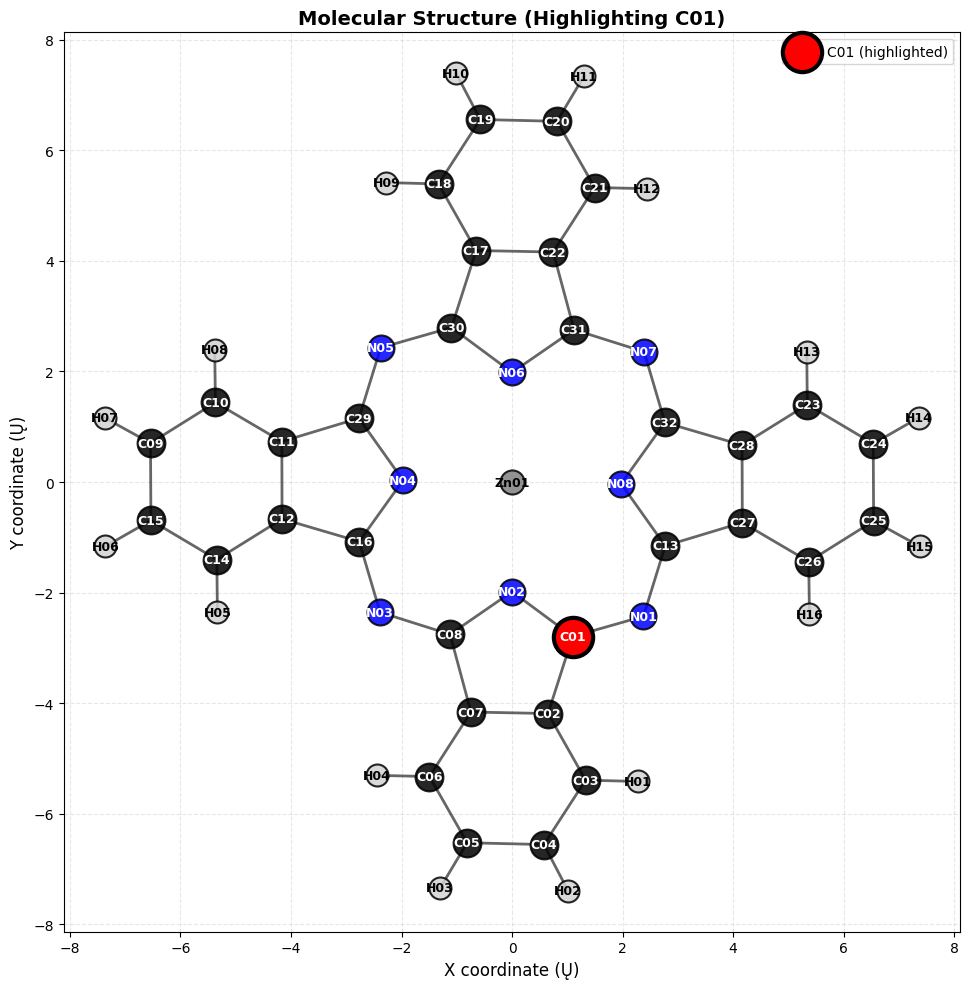

In [14]:
viz = MoleculeWireframe('improper-xyz.xyz')

# Single plot with highlighted atom
fig, ax = viz.plot(highlight_atom='C01', highlight_color='red')
plt.show()

In [12]:
"""
2D Molecular Wireframe with RDKit Drawing and Atom Highlighting

Generates publication-quality 2D chemical structure images directly from RDKit,
then optionally embeds them in matplotlib for further analysis/subplots.

Handles:
- All covalent bond types (single, double, triple, aromatic)
- Ligand bonds and coordination bonds
- Atom highlighting with custom colors
- Integration with matplotlib for multi-panel figures

Usage:
    viz = MoleculeWireframeRDKit('molecule.xyz')
    img = viz.draw(highlight_atom='N1', highlight_color=(1, 0, 0))
    img.show()

    # Or save directly
    viz.draw_and_save('molecule.xyz', 'output.png', highlight_atom='Zn1')
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from io import BytesIO

# RDKit imports
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole
from PIL import Image, ImageDraw, ImageFont

try:
    from rdkit.Chem import BondType
except ImportError:
    from rdkit.Chem.rdchem import BondType


def get_atom_type(atom_label):
    """Extract atom type from label like 'C01' -> 'C'"""
    return "".join(c for c in atom_label if c.isalpha())


def load_xyz(filename):
    """Load an XYZ file and return a DataFrame."""
    df = pd.read_csv(filename, sep=r"\s+", header=None, skiprows=2)
    df.columns = ["atom", "x", "y", "z"]
    return df


def save_xyz_file(df, filename, comment="Generated XYZ structure"):
    """Save DataFrame to standard XYZ file format."""
    n_atoms = len(df)
    with open(filename, "w") as f:
        f.write(f"{n_atoms}\n")
        f.write(f"{comment}\n")
        for _, row in df.iterrows():
            x = np.float32(row["x"])
            y = np.float32(row["y"])
            z = np.float32(row["z"])
            f.write(f"{row['atom']:<4} {x:>12.6f} {y:>12.6f} {z:>12.6f}\n")


def xyz_to_mol(xyz_file, smiles=None):
    """
    Convert XYZ file to RDKit molecule.

    Parameters
    ----------
    xyz_file : str or Path
        Path to XYZ file
    smiles : str, optional
        SMILES string for connectivity. If provided, used instead of distance-based bonding.

    Returns
    -------
    rdkit.Chem.Mol
        RDKit molecule object with 2D coordinates
    pandas.DataFrame
        DataFrame with atom labels from XYZ file
    """
    df = load_xyz(str(xyz_file))

    if smiles:
        # Build molecule from SMILES (preserves all bond types)
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES: {smiles}")

        mol = Chem.AddHs(mol)
        AllChem.Compute2DCoords(mol)

        # Relabel atoms to match XYZ file if possible
        # (This is optional - RDKit's labels are fine too)
        return mol, df

    else:
        # Fallback: try to infer connectivity from XYZ distances
        # This is limited for complex molecules - SMILES is recommended
        print("Warning: No SMILES provided. Inferring bonds from distances.")
        print("        For accurate bond types (aromatic, coordination), provide a SMILES string.")

        mol = infer_mol_from_xyz(df)
        AllChem.Compute2DCoords(mol)
        return mol, df


def infer_mol_from_xyz(df, distance_threshold=1.6):
    """
    Infer molecular connectivity from XYZ coordinates.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with columns ['atom', 'x', 'y', 'z']
    distance_threshold : float
        Multiplier for covalent radii bond detection

    Returns
    -------
    rdkit.Chem.Mol
        RDKit molecule with inferred bonds
    """
    covalent_radii = {
        "C": 0.76, "H": 0.31, "S": 1.05, "O": 0.66, "N": 0.71,
        "P": 1.07, "F": 0.57, "Cl": 0.99, "Br": 1.14, "I": 1.33,
        "Zn": 1.31, "Fe": 1.32, "Cu": 1.32, "Ni": 1.24,
    }

    # Create editable molecule
    em = Chem.EditableMol(Chem.Mol())

    # Add atoms
    for _, row in df.iterrows():
        atom_type = get_atom_type(row["atom"])
        atom = Chem.Atom(atom_type)
        em.AddAtom(atom)

    # Add bonds based on distance
    coords = df[["x", "y", "z"]].values
    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            atom_i = get_atom_type(df.iloc[i]["atom"])
            atom_j = get_atom_type(df.iloc[j]["atom"])

            r_i = covalent_radii.get(atom_i, 1.7)
            r_j = covalent_radii.get(atom_j, 1.7)
            bond_threshold = distance_threshold * (r_i + r_j) / 2

            dist = np.linalg.norm(coords[i] - coords[j])
            if dist < bond_threshold:
                em.AddBond(i, j, Chem.BondType.SINGLE)

    return em.GetMol()


class MoleculeWireframeRDKit:
    """2D wireframe using RDKit's native drawing engine."""

    def __init__(self, xyz_file, smiles=None):
        """
        Initialize with XYZ file and optional SMILES.

        Parameters
        ----------
        xyz_file : str or Path
            Path to XYZ file
        smiles : str, optional
            SMILES string for accurate connectivity/bond types.
            Highly recommended for complex molecules with ligands/coordination bonds.
        """
        self.xyz_file = Path(xyz_file)
        self.smiles = smiles

        # Load molecule and atoms
        self.mol, self.df = xyz_to_mol(str(self.xyz_file), smiles=smiles)

        print(f"✓ Loaded {self.mol.GetNumAtoms()} atoms from {self.xyz_file.name}")
        if smiles:
            print(f"  SMILES: {smiles}")
        print(f"  Bonds: {self.mol.GetNumBonds()}")

    def draw(
        self,
        highlight_atom=None,
        highlight_color=None,
        size=(400, 400),
        return_pil=False,
        atom_map=None,
    ):
        """
        Draw molecule with optional atom highlighting.

        Parameters
        ----------
        highlight_atom : str, optional
            Atom label from XYZ (e.g., 'N1', 'Zn1') to highlight.
            Note: RDKit uses its own atom indices internally.
        highlight_color : tuple or str, optional
            RGB color tuple (0-1 range) or matplotlib color name (default: red)
        size : tuple, optional
            Image size in pixels (width, height)
        return_pil : bool, optional
            If True, return PIL Image. If False, return numpy array.
        atom_map : dict, optional
            Mapping of RDKit atom indices to highlight colors.

        Returns
        -------
        PIL.Image or numpy.ndarray
            Drawn molecule image
        """
        if highlight_color is None:
            highlight_color = (1.0, 0.0, 0.0)  # Red
        elif isinstance(highlight_color, str):
            # Convert matplotlib color to RGB tuple
            import matplotlib.colors as mcolors
            highlight_color = mcolors.to_rgb(highlight_color)

        # Build atom highlight map
        highlight_map = {}
        if highlight_atom is not None:
            # Find RDKit atom index for given label
            rdkit_idx = self._find_atom_index(highlight_atom)
            if rdkit_idx is not None:
                highlight_map[rdkit_idx] = highlight_color

        if atom_map is not None:
            highlight_map.update(atom_map)

        # Draw molecule
        img = Draw.MolToImage(
            self.mol,
            size=size,
            highlightAtoms=list(highlight_map.keys()),
            highlightColor=highlight_map if highlight_map else None,
            kekulize=True,
        )

        if return_pil:
            return img
        else:
            return np.array(img)

    def draw_with_atom_labels(
        self,
        highlight_atom=None,
        highlight_color=None,
        size=(500, 500),
        label_size=12,
    ):
        """
        Draw molecule with XYZ atom labels overlaid.

        Combines RDKit's structure drawing with your custom XYZ labels.

        Parameters
        ----------
        highlight_atom : str, optional
            Atom label to highlight
        highlight_color : tuple, optional
            RGB color for highlight
        size : tuple, optional
            Image size
        label_size : int, optional
            Font size for labels

        Returns
        -------
        PIL.Image
            Image with atom labels
        """
        # Get base RDKit drawing
        img = self.draw(
            highlight_atom=highlight_atom,
            highlight_color=highlight_color,
            size=size,
            return_pil=True,
        )

        # Get atom coordinates from conformer
        conf = self.mol.GetConformer()

        # Scale coordinates to image size
        min_x = min(conf.GetAtomPosition(i).x for i in range(self.mol.GetNumAtoms()))
        max_x = max(conf.GetAtomPosition(i).x for i in range(self.mol.GetNumAtoms()))
        min_y = min(conf.GetAtomPosition(i).y for i in range(self.mol.GetNumAtoms()))
        max_y = max(conf.GetAtomPosition(i).y for i in range(self.mol.GetNumAtoms()))

        margin = 0.1
        x_range = max_x - min_x
        y_range = max_y - min_y

        def scale_coords(x, y):
            """Scale molecular coordinates to image pixel coordinates."""
            x_scaled = (x - min_x) / (x_range + 2 * margin * x_range) * size[0]
            y_scaled = (y - min_y) / (y_range + 2 * margin * y_range) * size[1]
            return int(x_scaled), int(y_scaled)

        # Draw labels on image
        draw = ImageDraw.Draw(img)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", label_size)
        except:
            font = ImageFont.load_default()

        for idx, row in self.df.iterrows():
            pos = conf.GetAtomPosition(idx)
            x_pix, y_pix = scale_coords(pos.x, pos.y)

            label = row["atom"]
            text_color = "white" if get_atom_type(label) in ["C", "N", "S"] else "black"

            # Draw label with background
            draw.text((x_pix - 5, y_pix - 5), label, fill=text_color, font=font)

        return img

    def show(self, highlight_atom=None, highlight_color=None):
        """Display molecule in Jupyter/IPython."""
        img = self.draw(highlight_atom=highlight_atom, highlight_color=highlight_color, return_pil=True)
        return img

    def save(self, output_path, highlight_atom=None, highlight_color=None, dpi=150):
        """Save molecule image to file."""
        img = self.draw(highlight_atom=highlight_atom, highlight_color=highlight_color, return_pil=True)
        img.save(output_path, dpi=(dpi, dpi))
        print(f"✓ Saved to {output_path}")

    def _find_atom_index(self, atom_label):
        """
        Find RDKit atom index for a given XYZ atom label.

        Note: This attempts to match by element type and order.
        For precise matching with complex molecules, direct index usage is better.
        """
        atom_type = get_atom_type(atom_label)
        atom_num = int("".join(c for c in atom_label if c.isdigit())) if any(c.isdigit() for c in atom_label) else 1

        count = 0
        for idx, atom in enumerate(self.mol.GetAtoms()):
            if atom.GetSymbol() == atom_type:
                count += 1
                if count == atom_num:
                    return idx

        print(f"Warning: Atom '{atom_label}' not found. Available atoms: {self.get_atom_list()}")
        return None

    def get_atom_list(self):
        """Return list of all atoms in the molecule."""
        atom_lists = {}
        for atom in self.mol.GetAtoms():
            symbol = atom.GetSymbol()
            if symbol not in atom_lists:
                atom_lists[symbol] = 0
            atom_lists[symbol] += 1

        return [f"{symbol}{i+1}" for symbol in sorted(atom_lists.keys()) for i in range(atom_lists[symbol])]

    def plot_in_matplotlib(
        self,
        highlight_atom=None,
        highlight_color=None,
        figsize=(10, 8),
        title=None,
        save_path=None,
    ):
        """
        Display RDKit-drawn molecule in matplotlib for multi-panel figures.

        Parameters
        ----------
        highlight_atom : str, optional
            Atom to highlight
        highlight_color : tuple, optional
            Highlight color
        figsize : tuple, optional
            Figure size
        title : str, optional
            Plot title
        save_path : str, optional
            Path to save figure

        Returns
        -------
        fig, ax : matplotlib figure and axes
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Get image from RDKit
        img_array = self.draw(
            highlight_atom=highlight_atom,
            highlight_color=highlight_color,
            return_pil=False,
        )

        # Display in matplotlib
        ax.imshow(img_array)
        ax.axis("off")

        if title is None:
            title = "Molecular Structure"
            if highlight_atom:
                title += f" ({highlight_atom} highlighted)"

        ax.set_title(title, fontsize=14, fontweight="bold", pad=20)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"✓ Saved to {save_path}")

        return fig, ax

    def plot_subplots(
        self,
        highlight_atoms=None,
        figsize=(16, 12),
        ncols=2,
        highlight_color=None,
        title_prefix="",
    ):
        """
        Create multiple 2D plots in a grid, each with different atom highlighted.

        Parameters
        ----------
        highlight_atoms : list of str, optional
            List of atom labels to highlight
        figsize : tuple, optional
            Total figure size
        ncols : int, optional
            Number of columns
        highlight_color : tuple, optional
            Highlight color
        title_prefix : str, optional
            Prefix for subplot titles

        Returns
        -------
        fig, axes : matplotlib figure and axes array
        """
        if highlight_atoms is None:
            highlight_atoms = [None]

        nrows = (len(highlight_atoms) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1 or ncols == 1:
            axes = axes.reshape(nrows, ncols)

        for idx, atom_label in enumerate(highlight_atoms):
            row = idx // ncols
            col = idx % ncols
            ax = axes[row, col]

            # Get image
            img_array = self.draw(
                highlight_atom=atom_label,
                highlight_color=highlight_color,
                return_pil=False,
            )

            ax.imshow(img_array)
            ax.axis("off")

            title = title_prefix
            if atom_label:
                title += f" ({atom_label})"
            ax.set_title(title, fontsize=11, fontweight="bold")

        # Hide unused subplots
        for idx in range(len(highlight_atoms), nrows * ncols):
            row = idx // ncols
            col = idx % ncols
            axes[row, col].axis("off")

        plt.tight_layout()
        return fig, axes


# ============================================================================
# CONVENIENCE FUNCTIONS
# ============================================================================

def draw_molecule_simple(xyz_file, smiles=None, highlight_atom=None, output_path=None):
    """
    Quick function: load XYZ, draw with RDKit, optionally save.

    Parameters
    ----------
    xyz_file : str
        Path to XYZ file
    smiles : str, optional
        SMILES string for connectivity
    highlight_atom : str, optional
        Atom to highlight
    output_path : str, optional
        Path to save image
    """
    viz = MoleculeWireframeRDKit(xyz_file, smiles=smiles)
    img = viz.draw(highlight_atom=highlight_atom, return_pil=True)

    if output_path:
        img.save(output_path)
        print(f"✓ Saved to {output_path}")

    return img


def compare_atoms(xyz_file, smiles=None, highlight_atoms=None):
    """
    Create a multi-panel figure highlighting different atoms.

    Parameters
    ----------
    xyz_file : str
        Path to XYZ file
    smiles : str, optional
        SMILES string
    highlight_atoms : list of str, optional
        Atoms to highlight in separate panels
    """
    viz = MoleculeWireframeRDKit(xyz_file, smiles=smiles)

    if highlight_atoms is None:
        # Auto-select interesting atoms
        highlight_atoms = [a for a in viz.get_atom_list() if not a.startswith("H")][:4]

    fig, axes = viz.plot_subplots(
        highlight_atoms=highlight_atoms,
        ncols=2,
        title_prefix="Molecular Structure"
    )
    return fig, axes


# ============================================================================
# EXAMPLES
# ============================================================================

def example_water_rdkit():
    """Example: water molecule."""
    water_xyz = """3
Water molecule
O    0.000000    0.000000    0.118720
H    0.000000    0.755453   -0.474880
H    0.000000   -0.755453   -0.474880"""

    xyz_path = "/tmp/water.xyz"
    with open(xyz_path, "w") as f:
        f.write(water_xyz)

    print("=" * 70)
    print("WATER MOLECULE - RDKit Drawing")
    print("=" * 70)

    # Water SMILES
    viz = MoleculeWireframeRDKit(xyz_path, smiles="O")
    img = viz.draw(highlight_atom="O1", highlight_color=(1, 0, 0), size=(400, 400))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Water - Oxygen Highlighted", fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/water_rdkit.png", dpi=150, bbox_inches="tight")
    print("✓ Saved to /mnt/user-data/outputs/water_rdkit.png")
    plt.close()


def example_complex_molecule():
    """Example: larger molecule with multiple heteroatoms."""
    # Create a simple benzene with substituents
    smiles = "c1ccc(cc1)N(C)C(=O)c2ccccc2"  # N,N-dimethylbenzamide

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.Compute2DCoords(mol)

    # Save as XYZ for consistency
    xyz_path = "/tmp/complex.xyz"
    atoms_data = []
    for atom in mol.GetAtoms():
        pos = mol.GetConformer().GetAtomPosition(atom.GetIdx())
        atoms_data.append({
            "atom": atom.GetSymbol(),
            "x": pos.x,
            "y": pos.y,
            "z": pos.z
        })

    df = pd.DataFrame(atoms_data)
    atom_counts = {}
    new_labels = []
    for atom_type in df["atom"]:
        atom_counts[atom_type] = atom_counts.get(atom_type, 0) + 1
        new_labels.append(f"{atom_type}{atom_counts[atom_type]}")
    df["atom"] = new_labels

    with open(xyz_path, "w") as f:
        f.write(f"{len(df)}\n{smiles}\n")
        for _, row in df.iterrows():
            f.write(f"{row['atom']:<4} {row['x']:>12.6f} {row['y']:>12.6f} {row['z']:>12.6f}\n")

    print("=" * 70)
    print("COMPLEX MOLECULE - Multiple Highlight Examples")
    print("=" * 70)

    viz = MoleculeWireframeRDKit(xyz_path, smiles=smiles)

    # Single plot with N highlighted
    fig, ax = viz.plot_in_matplotlib(
        highlight_atom="N1",
        highlight_color=(0, 0, 1),  # Blue
        title="N,N-dimethylbenzamide (N1 highlighted)"
    )
    plt.savefig("/mnt/user-data/outputs/complex_n1.png", dpi=150, bbox_inches="tight")
    print("✓ Saved N1 highlight")
    plt.close()

    # Multi-panel: highlight different atoms
    fig, axes = viz.plot_subplots(
        highlight_atoms=["N1", "N2", "O1"],
        ncols=3,
        title_prefix="Complex Molecule"
    )
    plt.savefig("/mnt/user-data/outputs/complex_multi.png", dpi=150, bbox_inches="tight")
    print("✓ Saved multi-panel comparison")
    plt.close()

In [ ]:
viz = MoleculeWireframeRDKit('molecule.xyz', smiles='CCO')

In [ ]:
from open